# Employee Attrition

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
train_data = pd.read_csv("C:\\Users\\Asus\\Downloads\\train_dataset.csv")
train_salary = pd.read_csv("C:\\Users\\Asus\\Downloads\\train_salaries.csv")
test = pd.read_csv("C:\\Users\\Asus\\Downloads\\test_dataset.csv")

In [5]:
train_data.head()

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
0,JOB1362684407687,COMP37,CFO,MASTERS,MATH,HEALTH,10,83
1,JOB1362684407688,COMP19,CEO,HIGH_SCHOOL,NONE,WEB,3,73
2,JOB1362684407689,COMP52,VICE_PRESIDENT,DOCTORAL,PHYSICS,HEALTH,10,38
3,JOB1362684407690,COMP38,MANAGER,DOCTORAL,CHEMISTRY,AUTO,8,17
4,JOB1362684407691,COMP7,VICE_PRESIDENT,BACHELORS,PHYSICS,FINANCE,8,16


In [6]:
train_salary.head()

,jobId,salary
0,JOB1362684407687,130
1,JOB1362684407688,101
2,JOB1362684407689,137
3,JOB1362684407690,142
4,JOB1362684407691,163


In [7]:
test.head()

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
0,JOB1362685407687,COMP33,MANAGER,HIGH_SCHOOL,NONE,HEALTH,22,73
1,JOB1362685407688,COMP13,JUNIOR,NONE,NONE,AUTO,20,47
2,JOB1362685407689,COMP10,CTO,MASTERS,BIOLOGY,HEALTH,17,9
3,JOB1362685407690,COMP21,MANAGER,HIGH_SCHOOL,NONE,OIL,14,96
4,JOB1362685407691,COMP36,JUNIOR,DOCTORAL,BIOLOGY,OIL,10,44


In [8]:
df = pd.merge(train_data, train_salary, on=['jobId'])

In [9]:
df.head()

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis,salary
0,JOB1362684407687,COMP37,CFO,MASTERS,MATH,HEALTH,10,83,130
1,JOB1362684407688,COMP19,CEO,HIGH_SCHOOL,NONE,WEB,3,73,101
2,JOB1362684407689,COMP52,VICE_PRESIDENT,DOCTORAL,PHYSICS,HEALTH,10,38,137
3,JOB1362684407690,COMP38,MANAGER,DOCTORAL,CHEMISTRY,AUTO,8,17,142
4,JOB1362684407691,COMP7,VICE_PRESIDENT,BACHELORS,PHYSICS,FINANCE,8,16,163


In [10]:
df.isnull().sum()

jobId                  0
companyId              0
jobType                0
degree                 0
major                  0
industry               0
yearsExperience        0
milesFromMetropolis    0
salary                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['jobId', 'companyId', 'jobType', 'degree', 'major', 'industry',
       'yearsExperience', 'milesFromMetropolis', 'salary'],
      dtype='object')

In [13]:
df.shape

(1000000, 9)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   jobId                1000000 non-null  object
 1   companyId            1000000 non-null  object
 2   jobType              1000000 non-null  object
 3   degree               1000000 non-null  object
 4   major                1000000 non-null  object
 5   industry             1000000 non-null  object
 6   yearsExperience      1000000 non-null  int64 
 7   milesFromMetropolis  1000000 non-null  int64 
 8   salary               1000000 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 68.7+ MB


In [15]:
df.describe()

,yearsExperience,milesFromMetropolis,salary
count,1000000.000000,1000000.000000,1000000.000000
mean,11.992386,49.529260,116.061818
std,7.212391,28.877733,38.717936
min,0.000000,0.000000,0.000000
25%,6.000000,25.000000,88.000000
50%,12.000000,50.000000,114.000000
75%,18.000000,75.000000,141.000000
max,24.000000,99.000000,301.000000


In [16]:
df.describe(include='object')

,jobId,companyId,jobType,degree,major,industry
count,1000000,1000000,1000000,1000000,1000000,1000000
unique,1000000,63,8,5,9,7
top,JOB1362684407687,COMP39,SENIOR,HIGH_SCHOOL,NONE,WEB
freq,1,16193,125886,236976,532355,143206


In [17]:
df.nunique()

jobId                  1000000
companyId                   63
jobType                      8
degree                       5
major                        9
industry                     7
yearsExperience             25
milesFromMetropolis        100
salary                     280
dtype: int64

In [18]:
num_col = df.select_dtypes(include=['int64']).columns
cat_col = df.select_dtypes(include=['object']).columns

In [19]:
print('Num_cols =',num_col)
print('Cat_cols =',cat_col)

Num_cols = Index(['yearsExperience', 'milesFromMetropolis', 'salary'], dtype='object')
Cat_cols = Index(['jobId', 'companyId', 'jobType', 'degree', 'major', 'industry'], dtype='object')


In [20]:
for i in cat_col:
    print(f"\n{i}")
    print(df[i].value_counts())


jobId
jobId
JOB1362684407687    1
JOB1362685074344    1
JOB1362685074346    1
JOB1362685074347    1
JOB1362685074348    1
                   ..
JOB1362684741024    1
JOB1362684741025    1
JOB1362684741026    1
JOB1362684741027    1
JOB1362685407686    1
Name: count, Length: 1000000, dtype: int64

companyId
companyId
COMP39    16193
COMP35    16114
COMP59    16066
COMP30    16041
COMP3     16028
          ...  
COMP17    15715
COMP0     15666
COMP2     15641
COMP8     15638
COMP57    15635
Name: count, Length: 63, dtype: int64

jobType
jobType
SENIOR            125886
VICE_PRESIDENT    125235
MANAGER           125121
CTO               125046
JANITOR           124971
CEO               124778
JUNIOR            124594
CFO               124369
Name: count, dtype: int64

degree
degree
HIGH_SCHOOL    236976
NONE           236854
BACHELORS      175495
DOCTORAL       175364
MASTERS        175311
Name: count, dtype: int64

major
major
NONE           532355
CHEMISTRY       58875
LITERATURE      

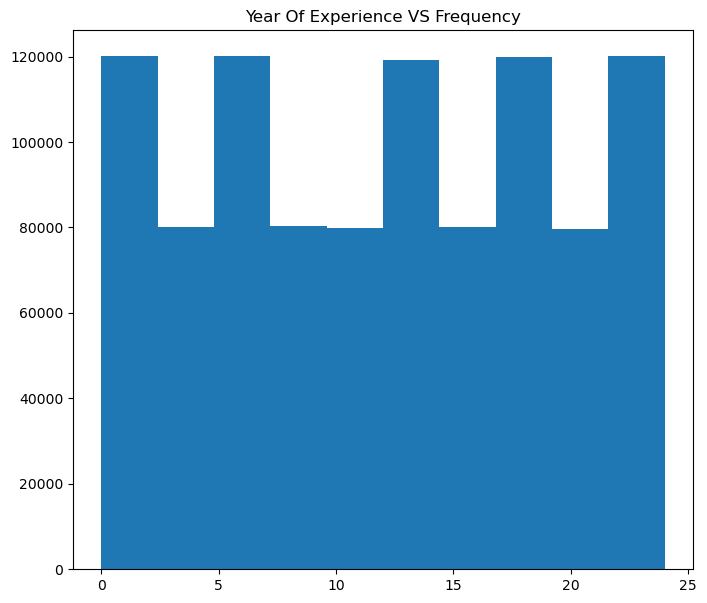

In [21]:
plt.figure(figsize=(8,7))
plt.hist(df['yearsExperience'])
plt.title('Year Of Experience VS Frequency')
plt.show()

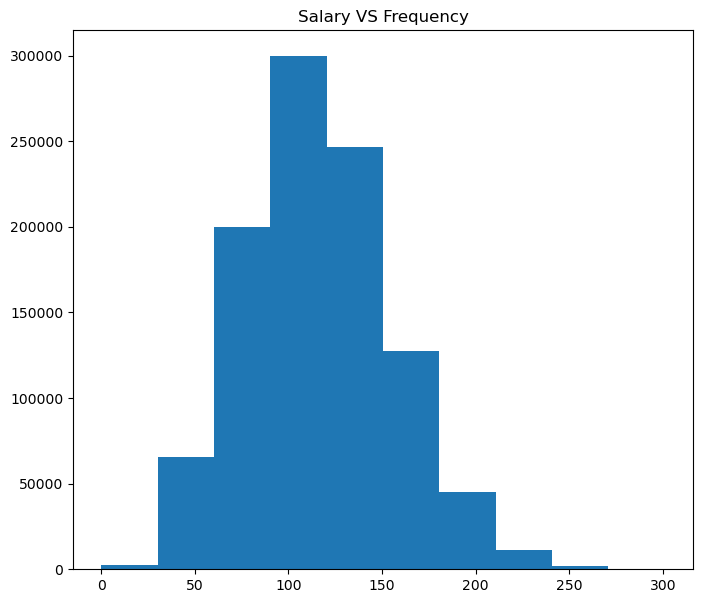

In [22]:
plt.figure(figsize=(8,7))
plt.hist(df['salary'])
plt.title('Salary VS Frequency')
plt.show()

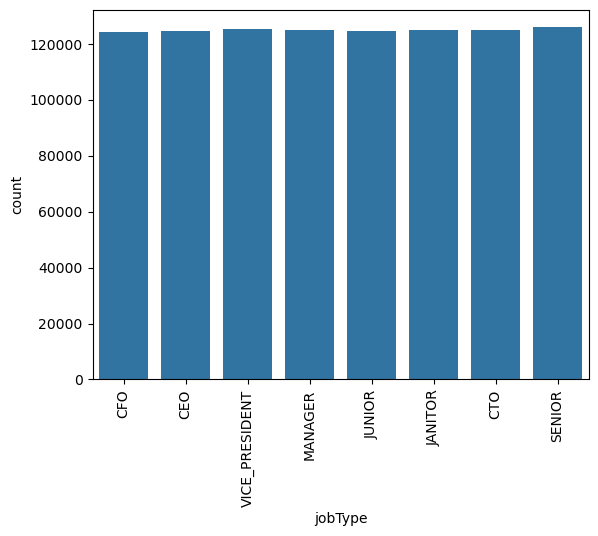

In [21]:
sns.countplot(x='jobType', data=df)
plt.xticks(rotation=90)
plt.show()

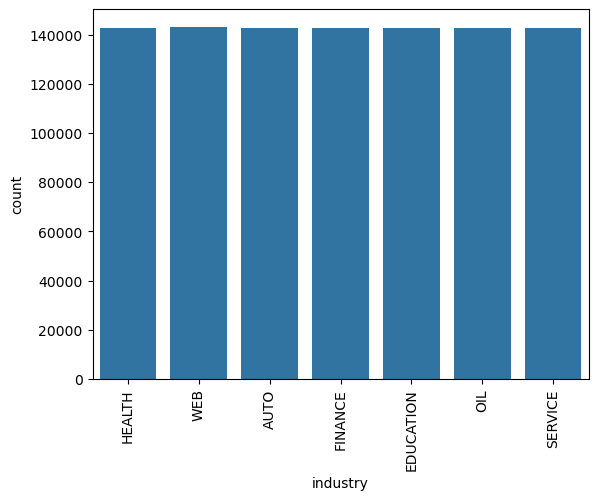

In [22]:
sns.countplot(x='industry', data=df)
plt.xticks(rotation=90)
plt.show()

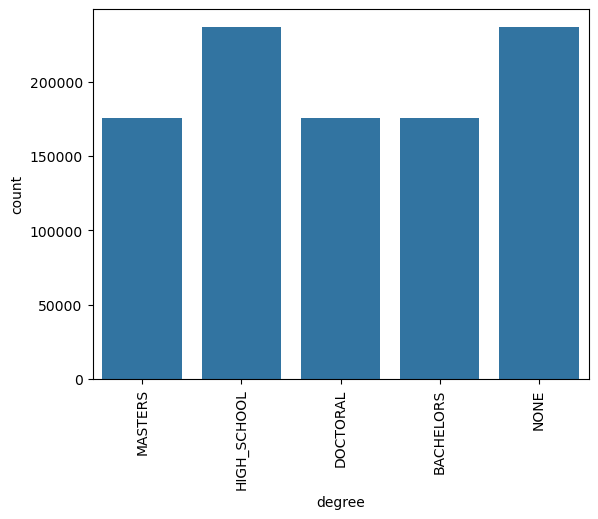

In [23]:
sns.countplot(x='degree', data=df)
plt.xticks(rotation=90)
plt.show()

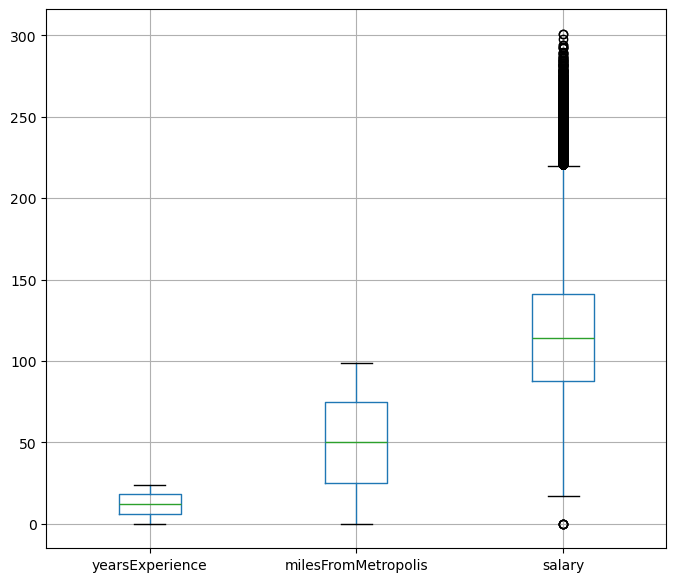

In [24]:
df.boxplot(figsize=(8,7))
plt.show()

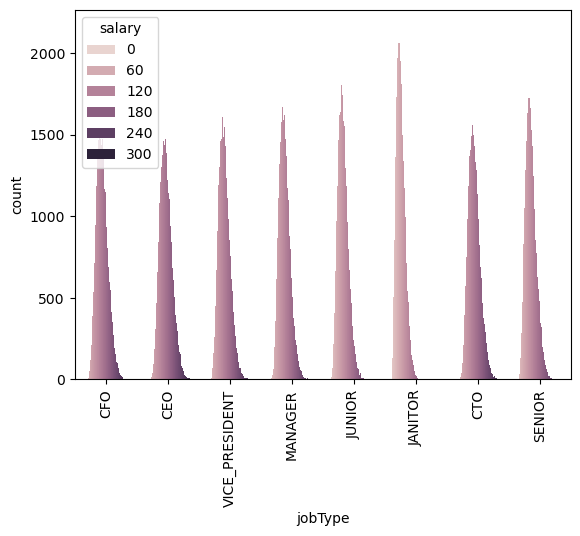

In [25]:
sns.countplot(x='jobType', hue='salary', data=df)
plt.xticks(rotation=90)
plt.show()

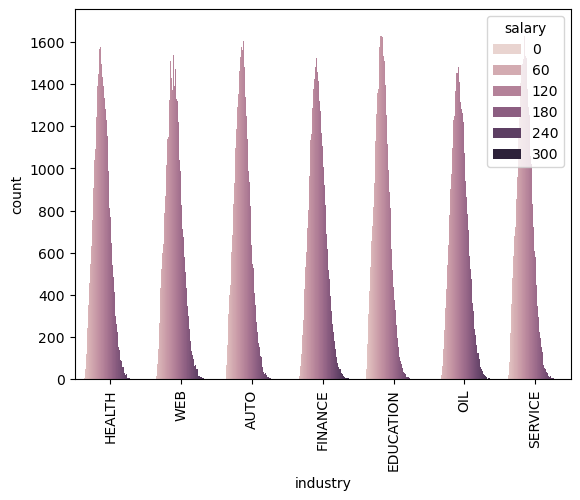

In [26]:
sns.countplot(x='industry', hue='salary', data=df)
plt.xticks(rotation=90)
plt.show()

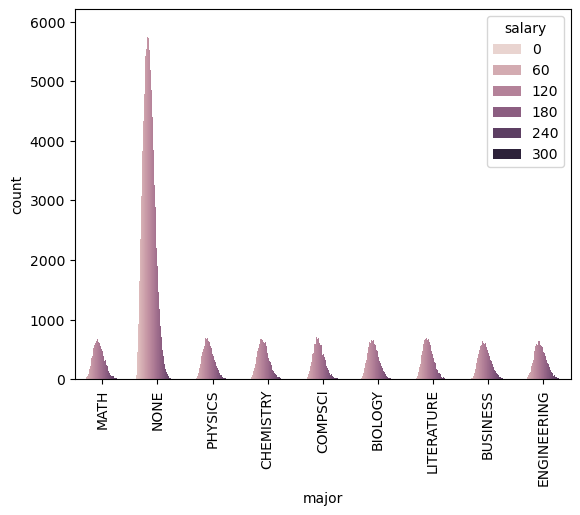

In [27]:
sns.countplot(x='major', hue='salary', data=df)
plt.xticks(rotation=90)
plt.show()

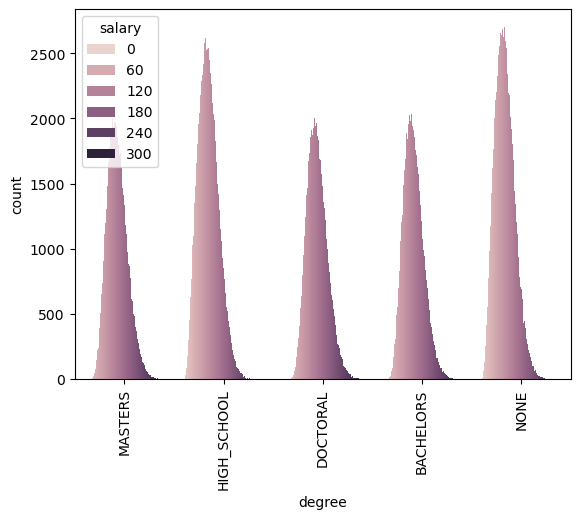

In [28]:
sns.countplot(x='degree', hue='salary', data=df)
plt.xticks(rotation=90)
plt.show()

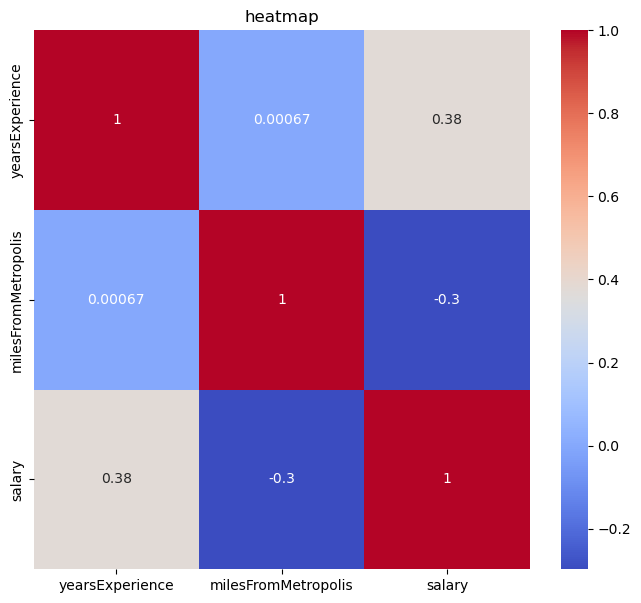

In [29]:
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('heatmap')
plt.show()

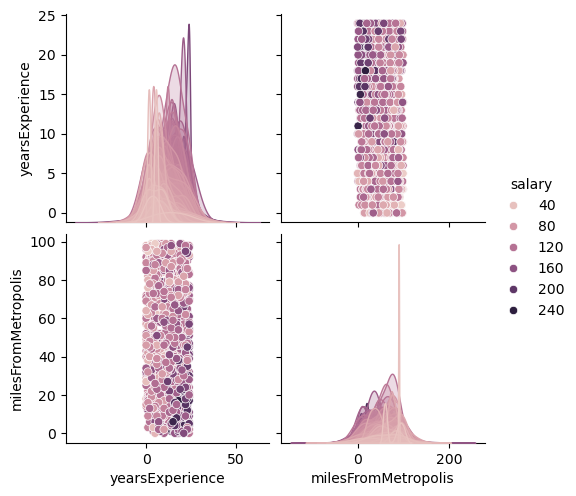

In [30]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df[['yearsExperience','milesFromMetropolis','salary']],
    hue='salary'
)

In [31]:
pd.crosstab(df['jobType'], df['salary'])

salary,0,17,18,19,20,21,22,23,24,25,...,286,287,288,289,290,292,293,294,298,301
jobType,,,,,,,,,,,,,,,,,,,,,
CEO,0,0,0,0,0,0,0,0,0,0,...,2,2,0,1,1,1,2,2,1,0
CFO,0,0,0,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
CTO,1,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,0,0,0,1
JANITOR,0,1,3,10,43,49,63,106,129,173,...,0,0,0,0,0,0,0,0,0,0
JUNIOR,2,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
MANAGER,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SENIOR,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VICE_PRESIDENT,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
pd.crosstab(df['degree'], df['salary'])

salary,0,17,18,19,20,21,22,23,24,25,...,286,287,288,289,290,292,293,294,298,301
degree,,,,,,,,,,,,,,,,,,,,,
BACHELORS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
DOCTORAL,2,0,0,0,0,0,0,0,0,0,...,2,1,2,1,1,0,2,1,0,1
HIGH_SCHOOL,1,0,2,2,21,32,36,48,58,85,...,0,0,0,0,0,0,0,0,0,0
MASTERS,1,0,0,0,0,0,0,0,0,0,...,1,1,0,2,0,1,0,0,1,1
NONE,1,1,1,8,22,17,27,59,71,88,...,0,0,0,0,0,0,0,0,0,0


In [33]:
for col in cat_col:
    if 'NONE' in df[col].values:
        print(f"{col}")
        print(df[col].value_counts())
        print("-"*50)

degree
degree
HIGH_SCHOOL    236976
NONE           236854
BACHELORS      175495
DOCTORAL       175364
MASTERS        175311
Name: count, dtype: int64
--------------------------------------------------
major
major
NONE           532355
CHEMISTRY       58875
LITERATURE      58684
ENGINEERING     58596
BUSINESS        58518
PHYSICS         58410
COMPSCI         58382
BIOLOGY         58379
MATH            57801
Name: count, dtype: int64
--------------------------------------------------


In [34]:
df.nunique()

jobId                  1000000
companyId                   63
jobType                      8
degree                       5
major                        9
industry                     7
yearsExperience             25
milesFromMetropolis        100
salary                     280
dtype: int64

In [35]:
df.select_dtypes(include='object').columns

Index(['jobId', 'companyId', 'jobType', 'degree', 'major', 'industry'], dtype='object')

In [36]:
df = df.drop(['jobId','companyId'],axis=1)

In [37]:
df = pd.get_dummies(df, columns=['jobType','degree','major','industry'],drop_first=True,dtype=int)

In [38]:
df.head()

,yearsExperience,milesFromMetropolis,salary,jobType_CFO,jobType_CTO,jobType_JANITOR,jobType_JUNIOR,jobType_MANAGER,jobType_SENIOR,jobType_VICE_PRESIDENT,...,major_LITERATURE,major_MATH,major_NONE,major_PHYSICS,industry_EDUCATION,industry_FINANCE,industry_HEALTH,industry_OIL,industry_SERVICE,industry_WEB
0,10,83,130,1,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1,3,73,101,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,10,38,137,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
3,8,17,142,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,16,163,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0


In [39]:
df_sample = df.sample(n=50000, random_state=42)

In [40]:
X = df_sample.drop('salary', axis=1)
y = df_sample['salary']

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LinearRegression
lr  = LinearRegression()
lr.fit(X_train,y_train)
lr_outcome = lr.predict(X_test)
print(lr_outcome)

[192.24846297  93.31676111 172.69863438 ... 123.37304459 136.38752414
 161.10874872]


In [44]:
from sklearn.metrics import r2_score
print(r2_score(y_test,lr_outcome))

0.7413195470497773


In [80]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
dt_outcome = dt.predict(X_test)
print(dt_outcome)

[184.  82. 139. ... 136.  84. 114.]


In [81]:
from sklearn.metrics import r2_score
print(r2_score(y_test,dt_outcome))

0.4579681088762423


In [84]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
rf_outcome = rf.predict(X_test)
print(rf_outcome)

[171.24  94.61 151.65 ... 115.94 119.67 136.98]


In [85]:
from sklearn.metrics import r2_score
print(r2_score(y_test,rf_outcome))

0.7017451232695386


In [49]:
from sklearn.ensemble import ExtraTreesRegressor
et = ExtraTreesRegressor(n_estimators=100, random_state=42)
et.fit(X_train, y_train)
et_outcome = et.predict(X_test)
print(et_outcome)

[179.87  95.15 147.77 ... 125.28 120.1  151.43]


In [50]:
from sklearn.metrics import r2_score
print(r2_score(y_test,et_outcome))

0.671596405799279


In [51]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
knn_outcome = knn.predict(X_test)
print(knn_outcome)

[185.   92.4 160.8 ... 129.8 126.2 165.6]


In [52]:
from sklearn.metrics import r2_score
print(r2_score(y_test,et_outcome))

0.671596405799279


In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_outcome = gbr.predict(X_test)

In [54]:
from sklearn.metrics import r2_score
print(r2_score(y_test,gbr_outcome))

0.7315454139363149


In [55]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
xgb_outcome = xgb.predict(X_test)

In [56]:
from sklearn.metrics import r2_score
print(r2_score(y_test,xgb_outcome))

0.740836501121521


In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
lr_result = [mean_absolute_error(y_test, lr_outcome),
    mean_squared_error(y_test, lr_outcome),
    np.sqrt(mean_squared_error(y_test, lr_outcome)),
    r2_score(y_test, lr_outcome)]

In [68]:
dt_result = [mean_absolute_error(y_test, dt_outcome),
    mean_squared_error(y_test, dt_outcome),
    np.sqrt(mean_squared_error(y_test, dt_outcome)),
    r2_score(y_test, dt_outcome)]

In [86]:
rf_result = [mean_absolute_error(y_test, rf_outcome),
    mean_squared_error(y_test, rf_outcome),
    np.sqrt(mean_squared_error(y_test, rf_outcome)),
    r2_score(y_test, rf_outcome)]

In [70]:
et_result = [mean_absolute_error(y_test, et_outcome),
    mean_squared_error(y_test, et_outcome),
    np.sqrt(mean_squared_error(y_test, et_outcome)),
    r2_score(y_test, et_outcome)]

In [71]:
knn_result = [mean_absolute_error(y_test, knn_outcome),
    mean_squared_error(y_test, knn_outcome),
    np.sqrt(mean_squared_error(y_test, knn_outcome)),
    r2_score(y_test, knn_outcome)]

In [72]:
gbr_result = [mean_absolute_error(y_test, gbr_outcome),
    mean_squared_error(y_test, gbr_outcome),
    np.sqrt(mean_squared_error(y_test, gbr_outcome)),
    r2_score(y_test, gbr_outcome)]

In [73]:
xgb_result = [mean_absolute_error(y_test, xgb_outcome),
    mean_squared_error(y_test, xgb_outcome),
    np.sqrt(mean_squared_error(y_test, xgb_outcome)),
    r2_score(y_test, xgb_outcome)]

In [87]:
result = pd.DataFrame(
    [
        lr_result,
        dt_result,
        rf_result,
        et_result,
        knn_result,
        gbr_result,
        xgb_result
    ],
    index = [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Extra Trees',
        'KNN',
        'Gradient Boosting',
        'XGBoost'
    ],
    columns = ['MAE', 'MSE', 'RMSE', 'R2 Score'] 
)

In [88]:
result.sort_values(by='R2 Score' , ascending=False)

,MAE,MSE,RMSE,R2 Score
Linear Regression,15.720145,378.145625,19.445967,0.741320
XGBoost,15.717612,378.851746,19.464114,0.740837
Gradient Boosting,15.940508,392.433700,19.809939,0.731545
Random Forest,16.637725,435.996518,20.880530,0.701745
KNN,17.097720,471.073856,21.704236,0.677750
Extra Trees,17.425492,480.068675,21.910470,0.671596
Decision Tree,21.948950,794.284064,28.183046,0.456649


In [91]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid = GridSearchCV(
    estimator = XGBRegressor(random_state=42),
    param_grid = param_grid,
    cv=5,
    scoring = 'r2',
    n_jobs=-1
)
grid.fit(X_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [93]:
print(grid.best_params_)
print(grid.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
0.7556727409362793


In [94]:
best_xgb = grid.best_estimator_

In [95]:
best_xgb_pred = best_xgb.predict(X_test)

In [96]:
xgb_tuned_result = [
    mean_absolute_error(y_test, best_xgb_pred),
    mean_squared_error(y_test, best_xgb_pred),
    np.sqrt(mean_squared_error(y_test, best_xgb_pred)),
    r2_score(y_test, best_xgb_pred)
]

print(xgb_tuned_result)

[15.451751708984375, 362.258544921875, np.float64(19.033090787412196), 0.7521874904632568]


In [97]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid = GridSearchCV(
    estimator = GradientBoostingRegressor(random_state=42),
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)
grid.fit(X_train,y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [98]:
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.7550437449925069


In [99]:
best_gbr = grid.best_estimator_

In [101]:
best_gbr_pred = best_gbr.predict(X_test)

In [102]:
gbr_tuned_result = [
    mean_absolute_error(y_test, best_gbr_pred),
    mean_squared_error(y_test, best_gbr_pred),
    np.sqrt(mean_squared_error(y_test, best_gbr_pred)),
    r2_score(y_test, best_gbr_pred)
]

print(gbr_tuned_result)

[15.476864913044945, 365.0083831614431, np.float64(19.10519257064537), 0.7503064224726929]


In [103]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
grid = GridSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)
grid.fit(X_train,y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [104]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
0.7330609714994372


In [105]:
best_rf = grid.best_estimator_

In [106]:
best_rf_pred = best_rf.predict(X_test)

In [107]:
rf_tuned_result = [
    mean_absolute_error(y_test, best_rf_pred),
    mean_squared_error(y_test, best_rf_pred),
    np.sqrt(mean_squared_error(y_test, best_rf_pred)),
    r2_score(y_test, best_rf_pred)
]

print(rf_tuned_result)

[15.952668966176017, 392.9490204060684, np.float64(19.822941769729045), 0.731192895239217]


In [108]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_xgb,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
print(scores)
print("Average R2 Score:", scores.mean())

[0.75998569 0.75246024 0.75348425 0.75291467 0.76010662]
Average R2 Score: 0.7557902932167053


In [109]:
import joblib

joblib.dump(best_xgb, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']

In [110]:
joblib.dump(scaler, "minmax_scaler.pkl")

['minmax_scaler.pkl']

In [111]:
model = joblib.load("salary_prediction_model.pkl")

scaler = joblib.load("minmax_scaler.pkl")

In [112]:
new_data = pd.DataFrame({
    'jobType': ['CEO'],
    'degree': ['MASTERS'],
    'major': ['BUSINESS'],
    'industry': ['FINANCE'],
    'yearsExperience': [12],
    'milesFromMetropolis': [8]
})

In [113]:
new_data = pd.get_dummies(new_data, columns = ['jobType','degree', 'major', 'industry'], drop_first=True, dtype=int)

In [2]:
new_data = new_data.reindex(columns=X.columns, fill_value=0)

NameError: name 'new_data' is not defined

In [116]:
new_data_scaled = scaler.transform(new_data)

In [117]:
new_data.head()

,yearsExperience,milesFromMetropolis,jobType_CFO,jobType_CTO,jobType_JANITOR,jobType_JUNIOR,jobType_MANAGER,jobType_SENIOR,jobType_VICE_PRESIDENT,degree_DOCTORAL,...,major_LITERATURE,major_MATH,major_NONE,major_PHYSICS,industry_EDUCATION,industry_FINANCE,industry_HEALTH,industry_OIL,industry_SERVICE,industry_WEB
0,12,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [118]:
new_data.shape

(1, 27)

In [119]:
prediction = best_xgb.predict(new_data_scaled)
print("Predicted Salary:", prediction[0])

Predicted Salary: 157.96725


In [24]:
import joblib

scaler = joblib.load("minmax_scaler.pkl")

print(scaler.feature_names_in_)

['yearsExperience' 'milesFromMetropolis' 'jobType_CFO' 'jobType_CTO'
 'jobType_JANITOR' 'jobType_JUNIOR' 'jobType_MANAGER' 'jobType_SENIOR'
 'jobType_VICE_PRESIDENT' 'degree_DOCTORAL' 'degree_HIGH_SCHOOL'
 'degree_MASTERS' 'degree_NONE' 'major_BUSINESS' 'major_CHEMISTRY'
 'major_COMPSCI' 'major_ENGINEERING' 'major_LITERATURE' 'major_MATH'
 'major_NONE' 'major_PHYSICS' 'industry_EDUCATION' 'industry_FINANCE'
 'industry_HEALTH' 'industry_OIL' 'industry_SERVICE' 'industry_WEB']
